<b>

<p>
<center>
<font size="6">
US Accident Severity Prediction Using Machine Learning
</font>
</center>
</p>

<p>
<center>
<font size="5">
Machine Learning I
</font>
</center>
</p>

<p>
<center>
<font size="5">
DATS 6202 - 10, Spring 2026
</font>
</center>
</p>

<p>
<center>
<font size="4">
Team Members
</font>
</center>
</p>

<p>
<center>
<font size="3">
Ilgaz Kusku<br>
Nazish Atta<br>
Alejandro Gomez
</font>
</center>
</p>

<p>
<center>
<font size="4">
Instructor
</font>
</center>
</p>

<p>
<center>
<font size="3">
Yuxiao (James) Huang
</font>
</center>
</p>

<p>
<center>
<font size="3">
George Washington University
</font>
</center>
</p>

</b>
<hr>

<h1>Table of Contents</h1>

<ul>

<li>1. Introduction</li>

<li>
2. Data Preparation
<ul>
<li><a href="#Import-Libraries-and-Load-Dataset">2.1 Import Libraries and Load Dataset</a></li>
<li><a href="#Find-CSV-File-and-Load-Data-Efficiently">2.2 Find CSV File and Load Data Efficiently</a></li>
<li><a href="#Save-Raw-Dataset-to-Google-Drive">2.3 Save Raw Dataset to Google Drive</a></li>
<li><a href="#Dataset-Overview-and-Data-Quality-Check">2.4 Dataset Overview and Data Quality Check</a></li>
<li><a href="#Data-Cleaning">2.5 Data Cleaning</a></li>
<li><a href="#Remove-Rows-with-Invalid-Dates">2.6 Remove Rows with Invalid Dates</a></li>
<li><a href="#Save-Cleaned-Dataset">2.7 Save Cleaned Dataset</a></li>
<li><a href="#Load-Cleaned-Dataset-for-Analysis">2.8 Load Cleaned Dataset for Analysis</a></li>
</ul>
</li>

<li>
3. Feature Engineering
<ul>
<li><a href="#Feature-Engineering-from-Date-and-Time">3.1 Feature Engineering from Date and Time</a></li>
<li><a href="#Save-Dataset-with-New-Features">3.2 Save Dataset with New Features</a></li>
</ul>
</li>

<li>
4. Exploratory Data Analysis
<ul>
<li><a href="#Exploratory-Data-Analysis-EDA">4.1 Exploratory Data Analysis (EDA)</a></li>
</ul>
</li>

<li>
5. Modeling
<ul>
<li><a href="#Prepare-Data-for-Modeling">5.1 Prepare Data for Modeling</a></li>
<li><a href="#Model-Evaluation-Function">5.2 Model Evaluation Function</a></li>
<li><a href="#Logistic-Regression-Model">5.3 Logistic Regression Model</a></li>
<li><a href="#Random-Forest-Model">5.4 Random Forest Model</a></li>
<li><a href="#LightGBM-Model">5.5 LightGBM Model</a></li>
<li><a href="#MLP-Neural-Network-Model">5.6 MLP Neural Network Model</a></li>
</ul>
</li>

<li>
6. Results and Conclusion
<ul>
<li><a href="#Final-Model-Comparison">6.1 Final Model Comparison</a></li>
<li><a href="#Conclusions">6.2 Conclusions</a></li>
</ul>
</li>

</ul>

**Note: Due to the large dataset size and model training time, this notebook is recommended to be run cell by cell. Full execution may take approximately 35-60 minutes, depending on the runtime environment. Intermediate datasets were saved to Google Drive to improve efficiency.**

# Introduction

Traffic accidents are a serious public safety problem. They can cause injuries, deaths, traffic delays, and economic loss.

Predicting accident severity can help emergency services, traffic agencies, and city planners respond faster and improve road safety.

For example, if a model predicts a high probability of a severe accident on a highway during heavy rain, authorities could:

- Alert police and ambulance teams earlier
- Recommend faster emergency routes
- Adjust nearby traffic control systems
- Suggest alternate routes to drivers
- Warn road agencies about dangerous conditions
- Allocate more resources to high-risk areas

This may reduce response time, traffic congestion, and possible injuries.

The goal of this project is to predict accident severity using historical accident data from the United States.

The dataset includes information such as:

- Date and time
- Location
- Weather conditions
- Road features
- Severity level

This project includes:

- Data cleaning
- Exploratory data analysis
- Handling class imbalance
- Training machine learning models
- Comparing model performance

## Import Libraries and Load Dataset

First, the required Python libraries are imported.

- `pandas` is used for data analysis.
- `matplotlib` is used for charts.
- `kagglehub` is used to download the dataset.

Then, the U.S. Accidents dataset is downloaded and the file path is displayed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    import kagglehub
except ImportError:
    !pip install -q kagglehub
    import kagglehub

path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print("Path to dataset files:", path)

100%|██████████| 653M/653M [00:45<00:00, 15.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13


## Find CSV File and Load Data Efficiently

First, the program searches for the CSV file inside the dataset folder.

After that, the dataset is loaded in smaller parts called chunks. This helps handle large data without using too much memory.

To save memory:

- Float columns are reduced to smaller numeric types
- Integer columns are reduced to smaller numeric types
- Text columns with few unique values are changed to category type

Finally, all chunks are combined into one DataFrame called `df`.

The shape, memory usage, and first rows of the dataset are displayed.

In [2]:
import os
import pandas as pd

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in: {path}")

full_csv_path = os.path.join(path, csv_files[0])
print(full_csv_path)

# Load in chunks
chunks = []
for chunk in pd.read_csv(full_csv_path, chunksize=500_000, low_memory=False):
    for col in chunk.select_dtypes('float').columns:
        chunk[col] = pd.to_numeric(chunk[col], downcast='float')
    for col in chunk.select_dtypes('integer').columns:
        chunk[col] = pd.to_numeric(chunk[col], downcast='integer')
    for col in chunk.select_dtypes('object').columns:
        if chunk[col].nunique() < 100:
            chunk[col] = chunk[col].astype('category')
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

/root/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13/US_Accidents_March23.csv
Shape: (7728394, 46)
Memory usage: 7317.6 MB


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


### Output

The dataset was loaded successfully.

- Rows: 7,728,394  
- Columns: 46  

This is a very large dataset.

## Save Raw Dataset to Google Drive

Google Drive is connected to the notebook.

Then, the original dataset is saved as a Parquet file.

Parquet format is useful because:

- It loads faster
- It uses less storage space
- It is efficient for large datasets

This file can be used later without loading the CSV again.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df.to_parquet('/content/drive/MyDrive/df_raw.parquet', index=False)
print(f"Raw saved shape: {df.shape}")

Mounted at /content/drive
Raw saved shape: (7728394, 46)


## Dataset Overview and Data Quality Check

This step explores the dataset and checks data quality before modeling.

The following information is reviewed:

- Total number of rows and columns
- Data types of each column
- Non-null values
- Missing values and percentages
- Duplicate rows and duplicate IDs
- Distribution of the target variable `Severity`
- Summary statistics for numeric columns
- Most common values in categorical columns
- Date range of the accident records

This step is important because it helps understand the dataset structure and possible problems such as missing data, duplicates, and class imbalance.

In [4]:
import pandas as pd
import numpy as np

print("=" * 50)
print("SHAPE")
print("=" * 50)
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("DTYPES & NON-NULL COUNTS")
print("=" * 50)
print(df.info(show_counts=True))

print("\n" + "=" * 50)
print("MISSING VALUES (%)")
print("=" * 50)
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df['missing_count'] > 0])

print("\n" + "=" * 50)
print("DUPLICATES")
print("=" * 50)
print(f"Fully duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate IDs: {df['ID'].duplicated().sum():,}")

print("\n" + "=" * 50)
print("TARGET VARIABLE (Severity)")
print("=" * 50)
print(df['Severity'].value_counts())
print(df['Severity'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n" + "=" * 50)
print("NUMERIC SUMMARY")
print("=" * 50)
print(df.describe().T)

print("\n" + "=" * 50)
print("CATEGORICAL SUMMARY (top 5 values each)")
print("=" * 50)
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(f"\n{col} — {df[col].nunique()} unique values")
    print(df[col].value_counts().head(5))

print("\n" + "=" * 50)
print("DATE RANGE")
print("=" * 50)
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
print(f"From: {df['Start_Time'].min()}")
print(f"To:   {df['Start_Time'].max()}")
print(f"Span: {(df['Start_Time'].max() - df['Start_Time'].min()).days} days")

SHAPE
Rows: 7,728,394  |  Columns: 46

DTYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   ID                     7728394 non-null  object  
 1   Source                 7728394 non-null  object  
 2   Severity               7728394 non-null  int8    
 3   Start_Time             7728394 non-null  object  
 4   End_Time               7728394 non-null  object  
 5   Start_Lat              7728394 non-null  float32 
 6   Start_Lng              7728394 non-null  float32 
 7   End_Lat                4325632 non-null  float32 
 8   End_Lng                4325632 non-null  float32 
 9   Distance(mi)           7728394 non-null  float32 
 10  Description            7728389 non-null  object  
 11  Street                 7717525 non-null  object  
 12  City                   7728141 non-null  object 

### Output

The dataset overview shows:

- 7,728,394 rows and 46 columns
- No duplicate rows or duplicate IDs
- Severity class is highly imbalanced  
  - Severity 2 = 79.67%  
  - Severity 1 = 0.87%
- Some columns have many missing values, especially:
  - End_Lat / End_Lng (44%)
  - Precipitation (28.5%)
  - Wind_Chill (25.9%)
- Data covers years 2016 to 2023

This output confirms the need for cleaning and imbalance handling.

## Data Cleaning

This step cleans the dataset before analysis and modeling.

First, columns with little value are removed. Some columns are removed because they have too many missing values, only one value, duplicated location information, or text that is not used in this model.

Next, extreme values are fixed. Very unrealistic values in temperature, wind speed, visibility, and pressure are changed to missing values.

After that, missing values are filled:

- Missing precipitation is changed to 0 because it probably means no rain.
- Missing numeric values are filled with the median.
- Missing text values are filled with `Unknown`.

Finally, date columns are converted to datetime format, and boolean columns are converted to numbers. This makes the data easier to use in machine learning models.

At the end, the code checks the new shape, memory usage, and remaining missing values.

In [5]:
# ============================================================
# CLEANING
# ============================================================

# 1. Drop useless columns
drop_cols = [
    'Country',       # only 1 value
    'End_Lat',       # 44% missing
    'End_Lng',       # 44% missing
    'Wind_Chill(F)', # 26% missing + correlated with Temperature
    'Description',   # free text, not useful for ML
    'Turning_Loop',  # all False, zero information
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

# 2. Fix obvious outliers
# Temperature: physically impossible beyond [-80, 140] F
df.loc[~df['Temperature(F)'].between(-80, 140), 'Temperature(F)'] = np.nan

# Wind speed: cap at 200 mph (strongest recorded tornado = ~135 mph)
df.loc[df['Wind_Speed(mph)'] > 200, 'Wind_Speed(mph)'] = np.nan

# Visibility: cap at 20 miles (standard clear-day max)
df.loc[df['Visibility(mi)'] > 20, 'Visibility(mi)'] = np.nan

# Pressure: must be physically plausible [25, 35] inHg
df.loc[~df['Pressure(in)'].between(25, 35), 'Pressure(in)'] = np.nan

# 3. Impute
# Precipitation: missing likely means no rain
df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0)

# Remaining numeric nulls: fill with median (robust to skew)
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Object columns: fill with 'Unknown'
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('Unknown')

# Category columns: must add 'Unknown' to categories first
for col in df.select_dtypes(include='category').columns:
    df[col] = df[col].cat.add_categories('Unknown').fillna('Unknown')

# 4. Fix dtypes
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time']   = pd.to_datetime(df['End_Time'],   errors='coerce')

# Bool columns -> int8 (friendlier for ML)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(np.int8)

# 5. Verify
print(f"\nShape after cleaning: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nRemaining nulls:\n{df.isna().sum()[df.isna().sum() > 0]}")


Shape after cleaning: (7728394, 40)
Memory: 5368.5 MB

Remaining nulls:
Start_Time    743166
End_Time      743166
dtype: int64


### Output

After cleaning:

- Dataset shape: 7,728,394 rows and 40 columns
- Memory reduced to 5.37 GB
- 6 columns were removed

Remaining missing values only exist in:

- Start_Time
- End_Time

This shows the dataset became cleaner and more memory efficient.

## Remove Rows with Invalid Dates

This step removes rows where `Start_Time` or `End_Time` could not be converted to a valid date and time.

These rows are not useful because time information is important for analysis and feature creation.

After removing them, the code shows:

- New dataset shape
- Number of rows removed
- Remaining missing values

This helps make sure the dataset is clean and ready for the next steps.

In [6]:
# Drop rows where Start_Time or End_Time couldn't be parsed
df.dropna(subset=['Start_Time', 'End_Time'], inplace=True)

print(f"Shape after dropping bad timestamps: {df.shape}")
print(f"Rows removed: {7728394 - len(df):,}")
print(f"Remaining nulls: {df.isna().sum().sum()}")

Shape after dropping bad timestamps: (6985228, 40)
Rows removed: 743,166
Remaining nulls: 0


## Save Cleaned Dataset

After cleaning, the dataset is saved as a Parquet file in Google Drive.

This is useful because:

- The cleaned data is ready for future use
- It loads faster than CSV files
- It saves storage space
- Cleaning does not need to be repeated again

The final dataset shape is also displayed.

In [7]:
df.to_parquet('/content/drive/MyDrive/df_cleaned.parquet', index=False)
print(f"Cleaned saved shape: {df.shape}")

Cleaned saved shape: (6985228, 40)


## Load Cleaned Dataset for Analysis

Google Drive is connected again to access the saved files.

Then, the required libraries are imported for data analysis and charts.

After that, the cleaned dataset is loaded from the Parquet file.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('/content/drive/MyDrive/df_cleaned.parquet')
print(f"Loaded: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: (6985228, 40)


## Feature Engineering from Date and Time

This step creates new useful features from the accident start and end times.

First, the date columns are converted to datetime format.

Then, several calendar features are created:

- Year
- Month
- Day
- Hour
- Minute
- Day of week
- Quarter
- Week of year

Next, behavior-based features are added:

- Weekend or not
- Part of day (Morning, Afternoon, Evening, Night)
- Morning rush hour
- Evening rush hour
- General rush hour
- Night time
- Business hours

Season is also created from the month:

- Winter
- Spring
- Summer
- Fall

After that, accident duration is calculated in minutes using start and end times.

Negative durations are removed, and very extreme durations are filtered using the 99th percentile.

Finally, cyclical features are created using sine and cosine transformations for:

- Hour
- Day of week
- Month

These features help the model understand repeating time patterns better.

At the end, the code shows the new shape, memory usage, and sample rows.

In [2]:
import numpy as np
import pandas as pd

# --- Datetime parsing ---
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time']   = pd.to_datetime(df['End_Time'],   errors='coerce')

# --- Basic calendar features ---
df['start_year']       = df['Start_Time'].dt.year
df['start_month']      = df['Start_Time'].dt.month
df['start_day']        = df['Start_Time'].dt.day
df['start_hour']       = df['Start_Time'].dt.hour
df['start_minute']     = df['Start_Time'].dt.minute
df['start_dayofweek']  = df['Start_Time'].dt.dayofweek
df['start_quarter']    = df['Start_Time'].dt.quarter
df['start_weekofyear'] = df['Start_Time'].dt.isocalendar().week.astype('Int64')

# --- Weekend ---
df['is_weekend'] = df['start_dayofweek'].isin([5, 6]).astype(np.int8)

# --- Part of day (vectorized) ---
bins   = [-1, 4, 11, 16, 20, 23]
labels = ['Night', 'Morning', 'Afternoon', 'Evening', 'Night2']
df['part_of_day'] = pd.cut(df['start_hour'], bins=bins, labels=labels)
df['part_of_day'] = df['part_of_day'].astype(str).replace('Night2', 'Night').astype('category')

# --- Rush hour ---
df['is_morning_rush'] = df['start_hour'].between(7, 9).astype(np.int8)
df['is_evening_rush'] = df['start_hour'].between(16, 18).astype(np.int8)
df['is_rush_hour']    = (df['is_morning_rush'] | df['is_evening_rush']).astype(np.int8)

# --- Night / business hours ---
df['is_night']          = df['start_hour'].isin([20,21,22,23,0,1,2,3,4,5]).astype(np.int8)
df['is_business_hours'] = df['start_hour'].between(9, 17).astype(np.int8)

# --- Season (vectorized) ---
bins   = [0, 2, 5, 8, 11, 12]
labels = ['Winter', 'Spring', 'Summer', 'Fall', 'Winter2']
df['season'] = pd.cut(df['start_month'], bins=bins, labels=labels)
df['season'] = df['season'].astype(str).replace('Winter2', 'Winter').astype('category')

# --- Duration ---
df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df.loc[df['duration_min'] < 0, 'duration_min'] = np.nan

# Cap at 99th percentile (data-driven, not hardcoded)
p99 = df['duration_min'].quantile(0.99)
print(f"99th percentile duration: {p99:.1f} min ({p99/60:.1f} hrs)")
df = df[df['duration_min'].between(0, p99)].copy()

# --- Cyclical encoding ---
df['hour_sin']      = np.sin(2 * np.pi * df['start_hour'] / 24)
df['hour_cos']      = np.cos(2 * np.pi * df['start_hour'] / 24)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['start_dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['start_dayofweek'] / 7)
df['month_sin']     = np.sin(2 * np.pi * df['start_month'] / 12)
df['month_cos']     = np.cos(2 * np.pi * df['start_month'] / 12)

# --- Verify ---
print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df[['Start_Time', 'End_Time', 'duration_min', 'part_of_day', 'season']].head()

99th percentile duration: 779.9 min (13.0 hrs)
Shape: (6915377, 63)
Memory: 5558.0 MB


,Start_Time,End_Time,duration_min,part_of_day,season
0,2016-02-08 05:46:00,2016-02-08 11:00:00,314.0,Morning,Winter
1,2016-02-08 06:07:59,2016-02-08 06:37:59,30.0,Morning,Winter
2,2016-02-08 06:49:27,2016-02-08 07:19:27,30.0,Morning,Winter
3,2016-02-08 07:23:34,2016-02-08 07:53:34,30.0,Morning,Winter
4,2016-02-08 07:39:07,2016-02-08 08:09:07,30.0,Morning,Winter


### Output

After feature engineering:

- Duration values above 13 hours were removed (99th percentile)
- Final shape: 6,915,377 rows and 63 columns
- Memory usage: 5.56 GB

New features were created, such as:

- `duration_min`
- `part_of_day`
- `season`

The sample rows confirm the new columns were added successfully.

## Save Dataset with New Features

After feature engineering, the updated dataset is saved as a Parquet file in Google Drive.

This file now includes the new time-based and behavior-based features.

Saving this version is useful because:

- The new features are ready for modeling
- Future notebooks can load the data quickly
- Feature engineering does not need to be repeated

The final dataset shape is also displayed.

In [3]:
df.to_parquet('/content/drive/MyDrive/df_features.parquet', index=False)
print(f"Features saved shape: {df.shape}")

Features saved shape: (6915377, 63)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('/content/drive/MyDrive/df_features.parquet')
print("Loaded:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: (6915377, 63)


## Exploratory Data Analysis (EDA)

This section uses charts to understand the data before modeling.

The analysis includes:

- Severity count and percentage
- Accidents by year and month
- Accidents by hour, day, and part of day
- Average severity by time features
- Top states and cities with most accidents
- Weather variable distributions
- Correlation heatmap for numeric features
- Accident duration distribution
- Road features compared with severity

EDA helps find patterns, class imbalance, and useful features for machine learning.

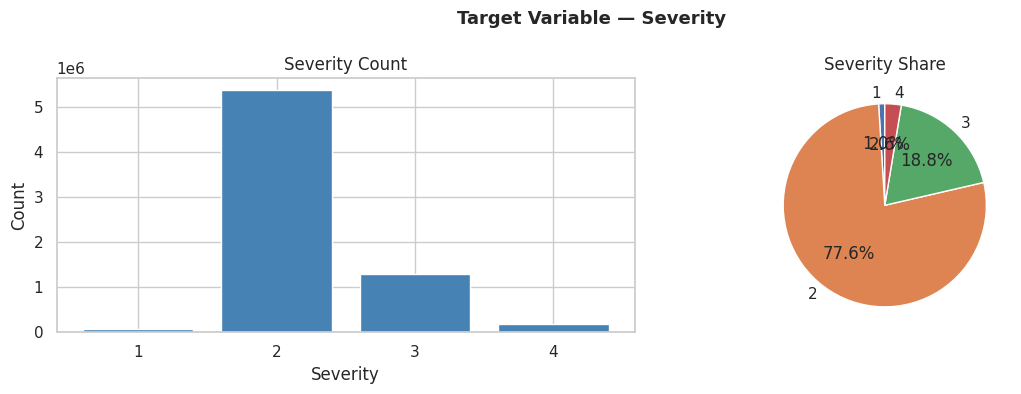

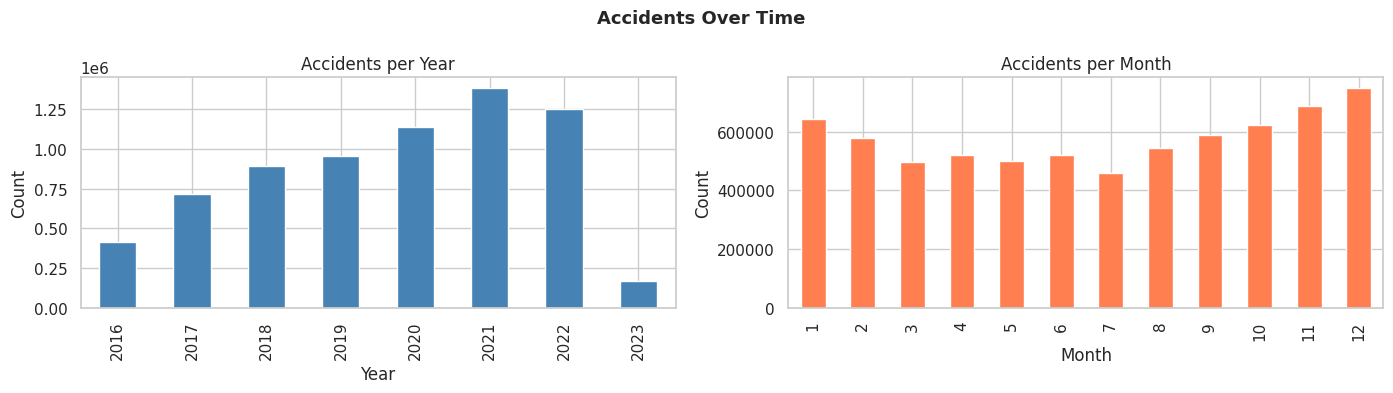

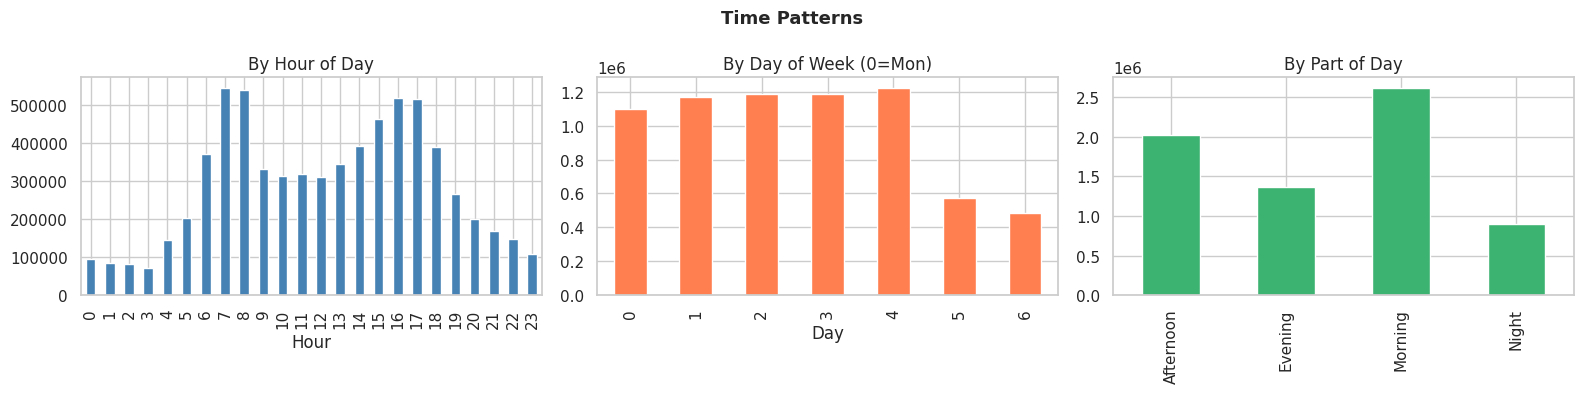

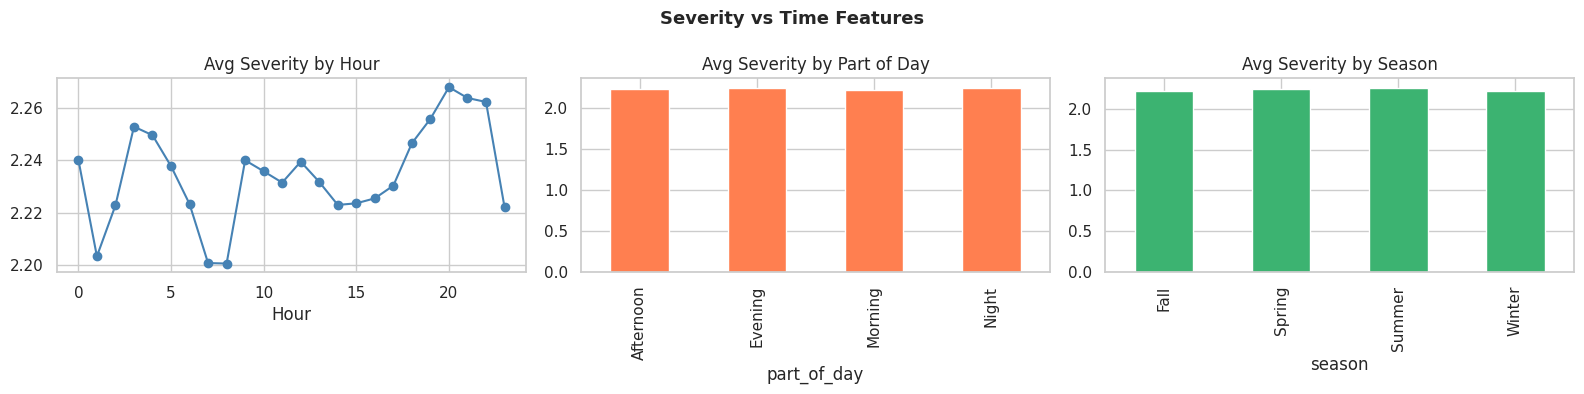

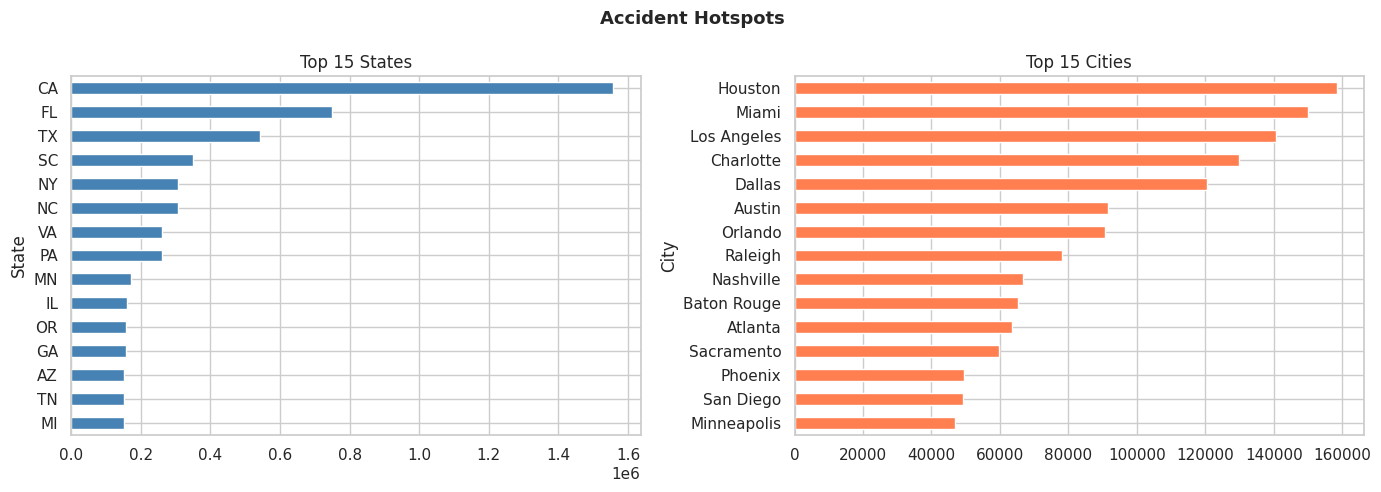

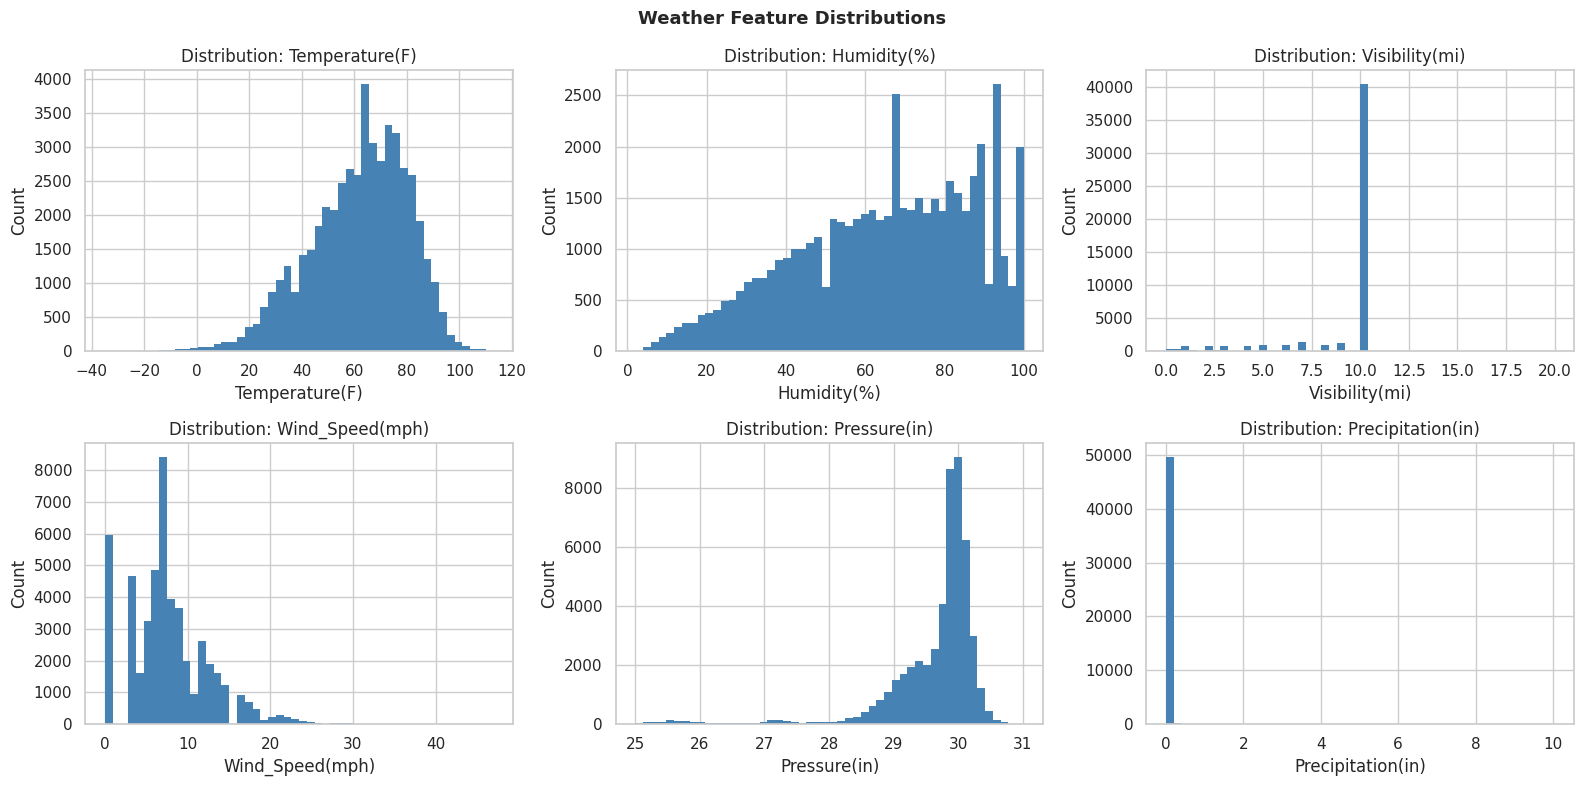

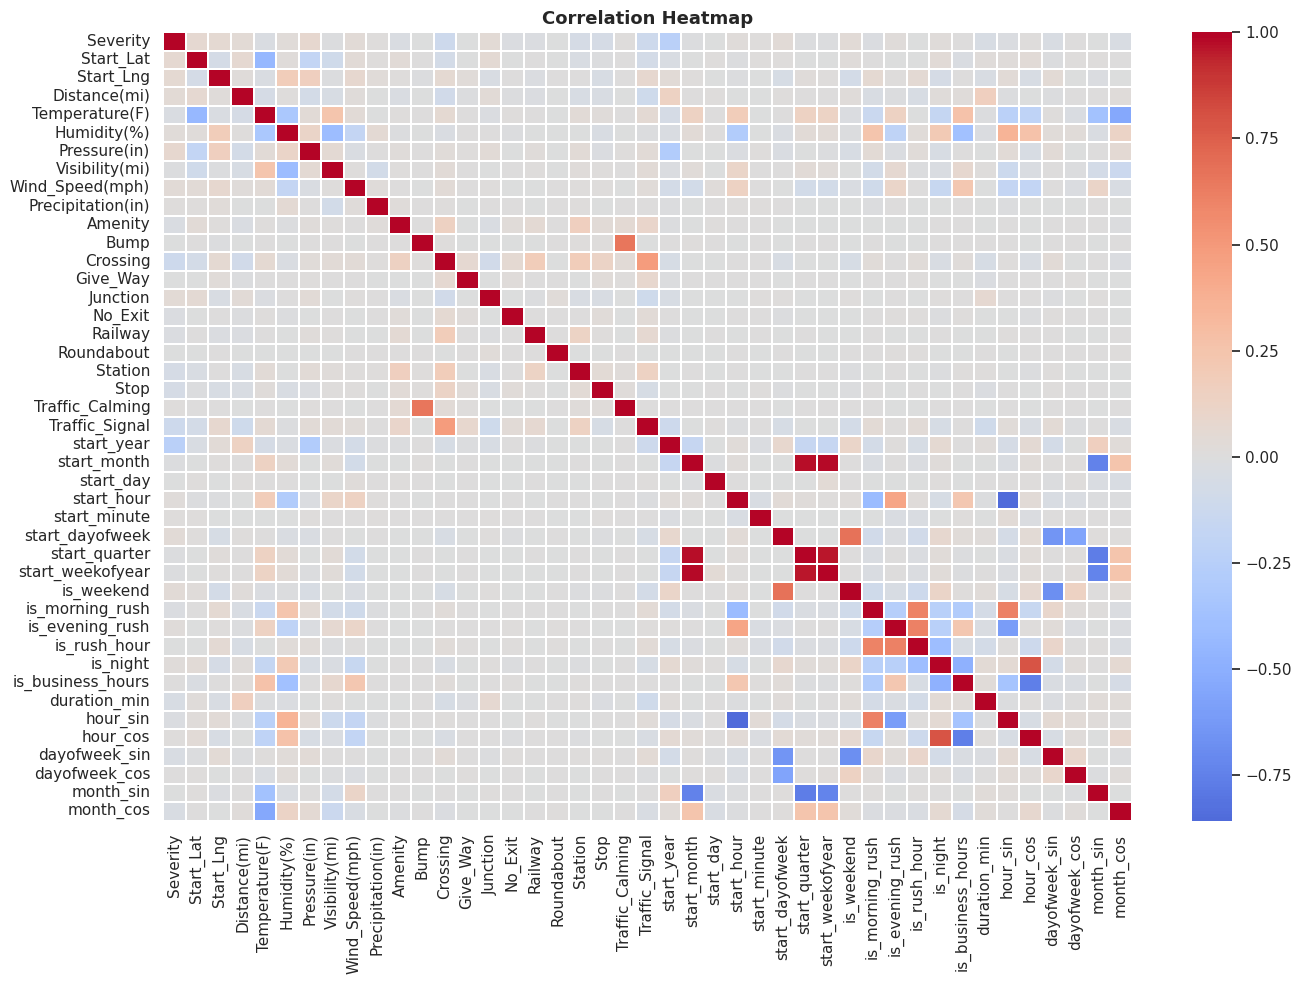

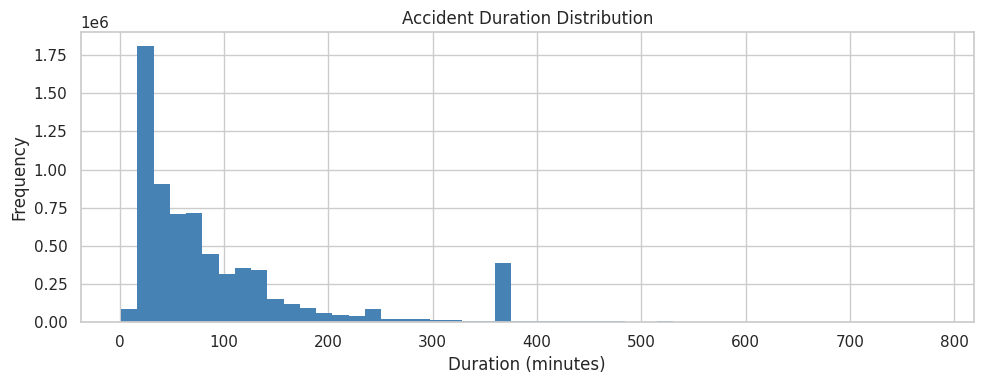

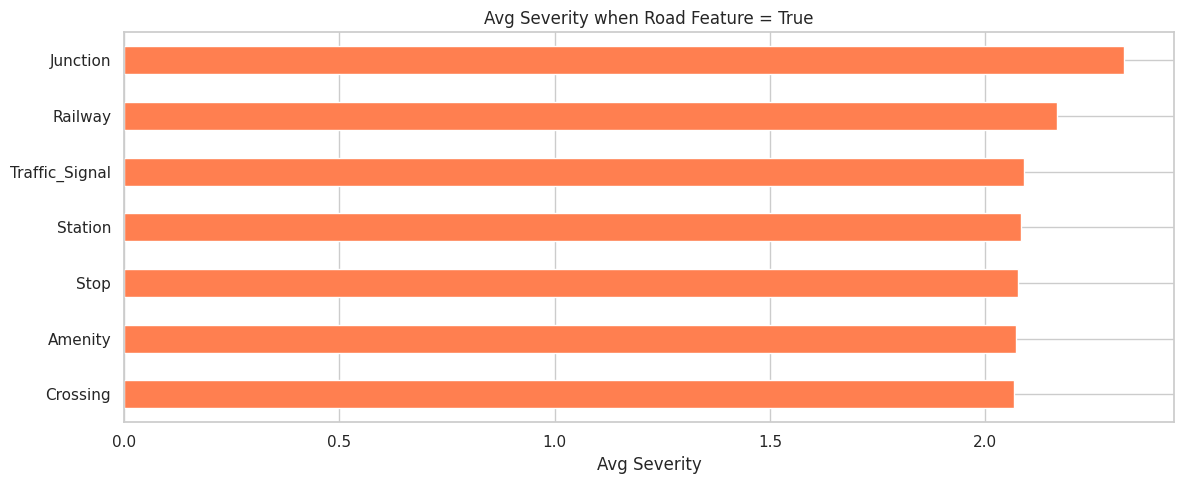

EDA complete


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

fig_kw = dict(figsize=(10, 4))

# ============================================================
# 1. TARGET — Severity distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = df['Severity'].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color='steelblue')
axes[0].set_title('Severity Count')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')

axes[1].pie(vc.values, labels=vc.index.astype(str), autopct='%1.1f%%', startangle=90)
axes[1].set_title('Severity Share')
plt.suptitle('Target Variable — Severity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 2. ACCIDENTS OVER TIME
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('start_year').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Accidents per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

df.groupby('start_month').size().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Accidents per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')

plt.suptitle('Accidents Over Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 3. TIME PATTERNS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df.groupby('start_hour').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('By Hour of Day')
axes[0].set_xlabel('Hour')

df.groupby('start_dayofweek').size().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('By Day of Week (0=Mon)')
axes[1].set_xlabel('Day')

df.groupby('part_of_day').size().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('By Part of Day')
axes[2].set_xlabel('')

plt.suptitle('Time Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 4. SEVERITY vs TIME FEATURES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df.groupby('start_hour')['Severity'].mean().plot(ax=axes[0], color='steelblue', marker='o')
axes[0].set_title('Avg Severity by Hour')
axes[0].set_xlabel('Hour')

df.groupby('part_of_day')['Severity'].mean().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Avg Severity by Part of Day')

df.groupby('season')['Severity'].mean().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Avg Severity by Season')

plt.suptitle('Severity vs Time Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 5. TOP STATES & CITIES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['State'].value_counts().head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 States')
axes[0].invert_yaxis()

df['City'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Cities')
axes[1].invert_yaxis()

plt.suptitle('Accident Hotspots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 6. WEATHER FEATURES vs SEVERITY
# ============================================================
weather_cols = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
                'Wind_Speed(mph)', 'Pressure(in)', 'Precipitation(in)']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

plot_df = df.sample(n=50_000, random_state=42)  # sample for speed

for i, col in enumerate(weather_cols):
    axes[i].hist(plot_df[col].dropna(), bins=50, color='steelblue', edgecolor='none')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Weather Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 7. CORRELATION HEATMAP (numeric only)
# ============================================================
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].sample(n=50_000, random_state=42).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3,
            annot=False, fmt='.1f')
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 8. DURATION DISTRIBUTION
# ============================================================
plt.figure(**fig_kw)
df['duration_min'].plot(kind='hist', bins=50, color='steelblue', edgecolor='none')
plt.title('Accident Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ============================================================
# 9. ROAD FEATURES vs SEVERITY
# ============================================================
road_features = ['Amenity', 'Crossing', 'Junction', 'Railway',
                 'Station', 'Stop', 'Traffic_Signal']

severity_by_feature = pd.DataFrame({
    col: df.groupby(col)['Severity'].mean()
    for col in road_features
}).T

plt.figure(figsize=(12, 5))
severity_by_feature[1].sort_values().plot(kind='barh', color='coral')
plt.title('Avg Severity when Road Feature = True')
plt.xlabel('Avg Severity')
plt.tight_layout()
plt.show()

print("EDA complete")

### Output

The exploratory data analysis shows several important patterns:

- Severity 2 is the dominant class, confirming strong class imbalance
- Accident counts increased from 2016 to 2021, then declined in later years
- Most accidents occur during morning and late afternoon rush hours
- Weekdays have more accidents than weekends
- California, Florida, and Texas have the highest accident counts
- Large cities such as Houston, Miami, and Los Angeles appear as hotspots
- Weather variables are mostly in normal ranges, with some skewed distributions
- Junctions, railways, and traffic signals are associated with higher average severity
- Accident duration is right-skewed, meaning most accidents are short but some last much longer

These insights help guide feature selection and model training.

## Prepare Data for Modeling

This step prepares the dataset for machine learning.

First, columns that are not useful for modeling are removed.

Dropped columns include:

- IDs, because they only identify rows
- Raw date columns, because new time features were already created
- Very specific location columns such as street, zipcode, city, and county, because they have many unique values and may add noise
- Some duplicated time columns, because transformed features were already available
- Twilight columns, because similar day/night information already exists

Other columns were kept because they may help prediction, such as:

- Weather variables
- State and general location coordinates
- Road condition indicators
- Engineered time features
- Duration and seasonal features

Then, the target variable is separated:

- `X` contains the input features
- `y` contains the accident severity

Text columns are converted into numbers because the selected models require numeric input.

Two stratified samples are created:

- 500,000 rows for larger models
- 100,000 rows for faster testing

The data is split into training and testing sets.

Finally, numeric features are scaled so models can train better.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# Feature selection
drop_for_model = [
    'ID', 'Start_Time', 'End_Time', 'Weather_Timestamp',
    'Street', 'Zipcode', 'Airport_Code', 'City', 'County',
    'start_hour', 'start_dayofweek', 'start_month',
    'is_morning_rush', 'is_evening_rush',
    'start_day', 'start_minute',
    'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
]
drop_for_model = [c for c in drop_for_model if c in df.columns]

X = df.drop(columns=drop_for_model + ['Severity'])
y = df['Severity']

for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X_500k, _, y_500k, _ = train_test_split(
    X, y, train_size=500_000, random_state=42, stratify=y
)
X_100k, _, y_100k, _ = train_test_split(
    X, y, train_size=100_000, random_state=42, stratify=y
)

X_train_lg, X_test_lg, y_train_lg, y_test_lg = train_test_split(
    X_500k, y_500k, test_size=0.2, random_state=42, stratify=y_500k
)
X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(
    X_100k, y_100k, test_size=0.2, random_state=42, stratify=y_100k
)

scaler = StandardScaler()
X_train_lg_sc = scaler.fit_transform(X_train_lg)
X_test_lg_sc  = scaler.transform(X_test_lg)
X_train_sm_sc = scaler.fit_transform(X_train_sm)
X_test_sm_sc  = scaler.transform(X_test_sm)

print(f"Features: {X.shape[1]}")
print("Splits ready")

Features: 43
Splits ready


## Model Evaluation Function

This function evaluates each machine learning model in the same way.

For each model, it calculates:

- Weighted F1-score
- F1-score for each severity class
- Training time
- Sample size
- Classification report
- Confusion matrix

The confusion matrix helps show which severity classes the model predicts correctly and where it makes mistakes.

The results are saved in a dictionary so the models can be compared later.

In [7]:
results = {}

def evaluate(name, model, X_test, y_test, train_time, sample_size):
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=[1,2,3,4])
    results[name] = {
        'weighted_f1':  f1,
        'f1_per_class': f1_per_class,
        'train_time':   train_time,
        'sample_size':  sample_size,
        'y_pred':       y_pred,
        'y_test':       y_test
    }
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Train time : {train_time:.1f}s")
    print(f"Sample size: {sample_size:,}")
    print(f"Weighted F1: {f1:.4f}")
    print(classification_report(y_test, y_pred,
          target_names=['Sev1','Sev2','Sev3','Sev4']))

    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred, labels=[1,2,3,4])
    ConfusionMatrixDisplay(cm, display_labels=[1,2,3,4]).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

print("evaluate() ready")

evaluate() ready


## Logistic Regression Model

This step trains a Logistic Regression model.

GridSearchCV tests different values and chooses the best one.

The tested values were:

- `C = 0.1, 1`  
  Controls model complexity. Lower values make the model simpler. Higher values allow more flexibility.

- `solver = lbfgs`  
  A fast method used to train Logistic Regression.

- `max_iter = 500`  
  Gives the model more time to finish training.

The model uses `class_weight='balanced'` to help minority severity classes.

`cv=3` means the model is tested on 3 different data splits.

The score used is weighted F1-score because the classes are imbalanced.

After training, the code shows:

- Best parameters
- Best cross-validation F1-score

Then, the best model is tested on the test data.

GridSearch — Logistic Regression...
Fitting 3 folds for each of 2 candidates, totalling 6 fits

Best params : {'C': 1, 'max_iter': 500, 'solver': 'lbfgs'}
Best CV F1  : 0.5166

Logistic Regression
Train time : 8.4s
Sample size: 100,000
Weighted F1: 0.5192
              precision    recall  f1-score   support

        Sev1       0.06      0.87      0.12       195
        Sev2       0.94      0.38      0.54     15528
        Sev3       0.41      0.71      0.52      3756
        Sev4       0.08      0.73      0.15       521

    accuracy                           0.45     20000
   macro avg       0.37      0.67      0.33     20000
weighted avg       0.81      0.45      0.52     20000



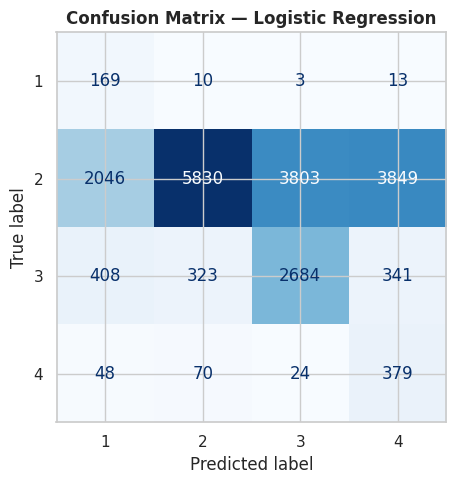

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

print("GridSearch — Logistic Regression...")
t0 = time.time()

param_grid_lr = {
    'C':        [0.1, 1],
    'solver':   ['lbfgs'],
    'max_iter': [500],
}

gs_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_lr, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1
)
gs_lr.fit(X_train_sm_sc, y_train_sm)

print(f"\nBest params : {gs_lr.best_params_}")
print(f"Best CV F1  : {gs_lr.best_score_:.4f}")

evaluate('Logistic Regression', gs_lr.best_estimator_,
         X_test_sm_sc, y_test_sm, time.time()-t0, 100_000)

### Output

The best settings were:

- `C = 1`
- `max_iter = 500`
- `solver = lbfgs`

Best CV score:

- **0.5166**

Test results:

- Weighted F1-score: **0.5192**
- Training time: **8.4 seconds**

Real observations:

- The model was fast, but performance was not strong.
- It predicted Severity 2 better than other classes because Severity 2 has most rows.
- Severity 3 was acceptable.
- Severity 1 and Severity 4 were weak.
- Many rows were predicted as Severity 2.

This is a simple baseline model, but not the best final model.

## Random Forest Model

This step trains a Random Forest model.

The tested values were:

- `n_estimators = 100, 200`  
  This is the number of trees. More trees can improve the model, but they also take more time.

- `max_depth = 10, 15`  
  This controls how deep each tree can grow. Deeper trees can learn more patterns, but they can also overfit.

The model uses `class_weight='balanced'` to help minority severity classes.

`cv=3` tests the model on 3 different data splits.

The score used is weighted F1-score because the severity classes are imbalanced.

After training, the best model is tested on the test data.

Finally, memory is cleared because Random Forest can use a lot of memory.

GridSearch — Random Forest...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best params : {'max_depth': 15, 'n_estimators': 200}
Best CV F1  : 0.7686

Random Forest
Train time : 217.6s
Sample size: 100,000
Weighted F1: 0.7589
              precision    recall  f1-score   support

        Sev1       0.34      0.83      0.48       195
        Sev2       0.93      0.74      0.82     15528
        Sev3       0.46      0.78      0.58      3756
        Sev4       0.23      0.38      0.29       521

    accuracy                           0.74     20000
   macro avg       0.49      0.68      0.54     20000
weighted avg       0.82      0.74      0.76     20000



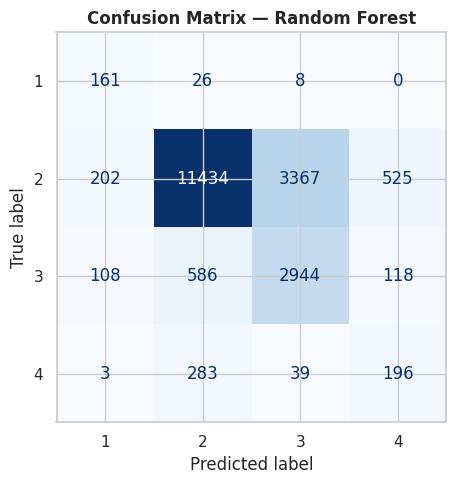

21787

In [9]:
from sklearn.ensemble import RandomForestClassifier
import gc

print("GridSearch — Random Forest...")
t0 = time.time()

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 15],
}

gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_rf, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1
)
gs_rf.fit(X_train_sm, y_train_sm)

print(f"\nBest params : {gs_rf.best_params_}")
print(f"Best CV F1  : {gs_rf.best_score_:.4f}")

evaluate('Random Forest', gs_rf.best_estimator_,
         X_test_sm, y_test_sm, time.time()-t0, 100_000)

del gs_rf
gc.collect()

### Output

The best settings were:

- `n_estimators = 200`
- `max_depth = 15`

Best CV score:

- **0.7686**

Test results:

- Weighted F1-score: **0.7589**
- Training time: **217.6 seconds**

Real observations:

- This model performed much better than Logistic Regression.
- Severity 2 was predicted very well.
- Severity 3 had good results.
- Severity 1 was acceptable.
- Severity 4 was still weak because it has fewer rows.
- Most predictions were correct in the confusion matrix.

This is a stronger model, but training was slower.

## LightGBM Model

This step trains a LightGBM model, a fast and strong boosting model for tabular data.

The tested values were:

- `learning_rate = 0.05, 0.1`  
  Controls how fast the model learns. Lower values learn slower and can improve accuracy. Higher values train faster.

- `num_leaves = 31, 63`  
  Controls tree complexity. More leaves can learn more patterns, but may overfit.

Fixed values used:

- `n_estimators = 200`  
  Number of boosting trees. Good balance between speed and performance.

- `max_depth = 6`  
  Limits tree depth to reduce overfitting.

The model uses `class_weight='balanced'` to help minority severity classes.

`cv=2` was used to reduce training time because the dataset is large.

The score used is weighted F1-score because the classes are imbalanced.

After training, the best model is tested on the test data.

Finally, the best LightGBM model is saved to Google Drive for future use.

GridSearch — LightGBM...
Fitting 2 folds for each of 4 candidates, totalling 8 fits

Best params : {'learning_rate': 0.1, 'num_leaves': 63}
Best CV F1  : 0.7661

LightGBM
Train time : 646.3s
Sample size: 500,000
Weighted F1: 0.7595
              precision    recall  f1-score   support

        Sev1       0.34      0.95      0.50       974
        Sev2       0.97      0.69      0.81     77639
        Sev3       0.52      0.83      0.64     18779
        Sev4       0.17      0.80      0.29      2608

    accuracy                           0.72    100000
   macro avg       0.50      0.82      0.56    100000
weighted avg       0.86      0.72      0.76    100000



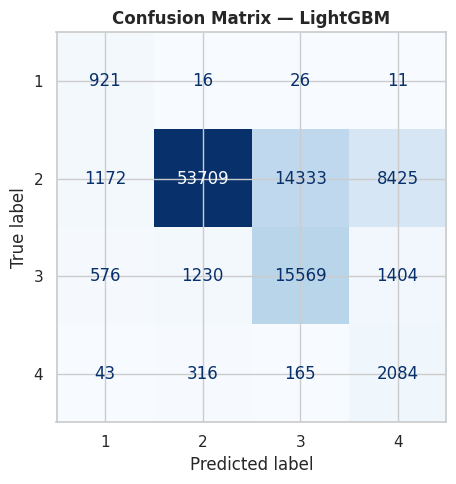

LightGBM saved to Drive


In [10]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

print("GridSearch — LightGBM...")
t0 = time.time()

param_grid_lgbm = {
    'learning_rate': [0.05, 0.1],
    'num_leaves':    [31, 63],
}

gs_lgbm = GridSearchCV(
    lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    param_grid_lgbm,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
gs_lgbm.fit(X_train_lg, y_train_lg)

print(f"\nBest params : {gs_lgbm.best_params_}")
print(f"Best CV F1  : {gs_lgbm.best_score_:.4f}")

evaluate('LightGBM', gs_lgbm.best_estimator_,
         X_test_lg, y_test_lg, time.time()-t0, 500_000)

lgbm_best = gs_lgbm.best_estimator_

import joblib
joblib.dump(lgbm_best, '/content/drive/MyDrive/lgbm_best.pkl')
print("LightGBM saved to Drive")

### Output

The best settings were:

- `learning_rate = 0.1`
- `num_leaves = 63`

Best CV score:

- **0.7661**

Test results:

- Weighted F1-score: **0.7595**
- Training time: **646.3 seconds**

Real observations:

- This was the best model overall.
- It gave the highest weighted F1-score.
- Severity 2 was predicted very well.
- Severity 3 had good results.
- Severity 1 had strong recall.
- Severity 4 was still difficult, but recall was good.
- The model balanced performance across classes better than other models.

This was the strongest final model, but it needed the most training time.

## MLP Neural Network Model

This step trains an MLP (Multi-Layer Perceptron) neural network.

First, the training data is balanced by upsampling minority classes. This gives each severity class the same number of rows.

A smaller sample is used to reduce training time.

The input data is scaled because neural networks work better with scaled numeric values.

The model was trained with:

- `hidden_layer_sizes = (128, 64)`  
  Two hidden layers to learn more complex patterns.

- `activation = relu`  
  A common and fast activation function.

- `learning_rate_init = 0.001`  
  A safe learning speed for stable training.

- `max_iter = 30`  
  Limits training time.

- `early_stopping = True`  
  Stops training when performance no longer improves.

- `validation_fraction = 0.1`  
  Uses 10% of training data for validation.

After training, the model is tested using the evaluation function.

Balancing training data for MLP...
Balanced: (248444, 43)

Training MLP...
Iteration 1, loss = 0.64114451
Validation score: 0.788287
Iteration 2, loss = 0.47118227
Validation score: 0.823546
Iteration 3, loss = 0.41245560
Validation score: 0.837191
Iteration 4, loss = 0.37662149
Validation score: 0.851117
Iteration 5, loss = 0.34885730
Validation score: 0.863514
Iteration 6, loss = 0.32672518
Validation score: 0.869833
Iteration 7, loss = 0.31009566
Validation score: 0.874743
Iteration 8, loss = 0.29648987
Validation score: 0.877360
Iteration 9, loss = 0.28291994
Validation score: 0.880499
Iteration 10, loss = 0.27393713
Validation score: 0.885691
Iteration 11, loss = 0.26466154
Validation score: 0.888267
Iteration 12, loss = 0.25673703
Validation score: 0.888388
Iteration 13, loss = 0.25015211
Validation score: 0.894184
Iteration 14, loss = 0.24459561
Validation score: 0.893500
Iteration 15, loss = 0.24051916
Validation score: 0.893379
Iteration 16, loss = 0.23569351
Validation score:

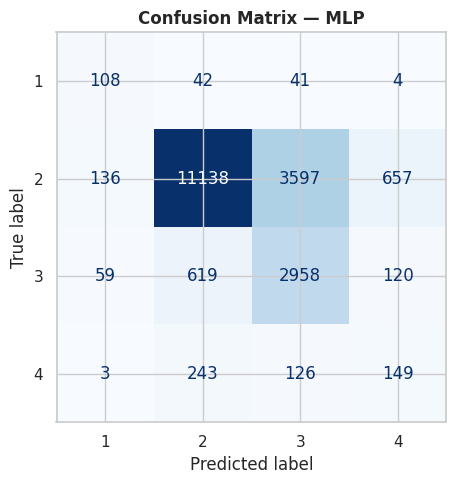

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
import time

print("Balancing training data for MLP...")

# Use smaller sample to keep MLP fast
X_train_mlp_df = X_train_sm.copy()
y_train_mlp_s  = y_train_sm.copy()

train_data = pd.concat([X_train_mlp_df, y_train_mlp_s.rename('Severity')], axis=1)
max_size = train_data['Severity'].value_counts().max()

upsampled = []
for sev in train_data['Severity'].unique():
    subset = train_data[train_data['Severity'] == sev]
    upsampled.append(resample(subset, replace=True,
                              n_samples=max_size, random_state=42))

train_balanced = pd.concat(upsampled)
X_train_mlp = scaler.transform(train_balanced.drop(columns='Severity'))
y_train_mlp  = train_balanced['Severity']
print(f"Balanced: {X_train_mlp.shape}")

# Single config - no GridSearch, too slow for MLP
print("\nTraining MLP...")
t0 = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=True
)
mlp.fit(X_train_mlp, y_train_mlp)

evaluate('MLP', mlp, X_test_sm_sc, y_test_sm,
         time.time()-t0, 100_000)

### Output

The training data was balanced to help minority classes.

Balanced training shape:

- **248,444 rows**
- **43 features**

Test results:

- Weighted F1-score: **0.7429**
- Training time: **108.9 seconds**

Real observations:

- The model was decent, but weaker than Random Forest and LightGBM.
- Severity 2 was predicted well because it is the largest class.
- Severity 3 was acceptable.
- Severity 1 was moderate, not strong.
- Severity 4 was poor.
- Many predictions were still pushed toward Severity 2 and 3.
- The validation score improved during training, so learning was stable.

This model worked, but it was not one of the top models for this dataset.

## Final Model Comparison

This step compares all trained models in one place.

The summary table shows:

- Weighted F1-score
- F1-score for each severity class
- Training time
- Sample size

The charts compare:

- Overall model performance
- Performance by severity class
- Training time versus F1-score
- Most important features from LightGBM

The best model is selected using the highest weighted F1-score.

This comparison is important because the fastest model is not always the best model, and the best overall model may still have weak results for rare classes.


FINAL MODEL COMPARISON
                    Weighted F1 F1 Sev1 F1 Sev2 F1 Sev3 F1 Sev4 Train Time Sample Size
Logistic Regression      0.5192  0.1179  0.5358  0.5227  0.1485       8.4s     100,000
Random Forest            0.7589  0.4813  0.8209  0.5822  0.2882     217.6s     100,000
LightGBM                 0.7595  0.4997  0.8082  0.6371  0.2868     646.3s     500,000
MLP                      0.7429  0.4311  0.8080  0.5646  0.2054     108.9s     100,000


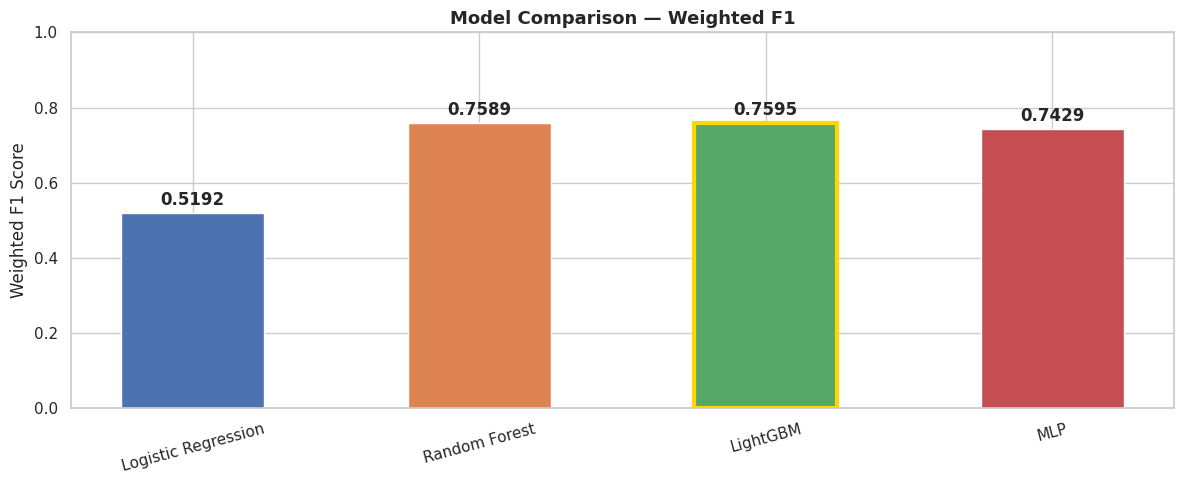

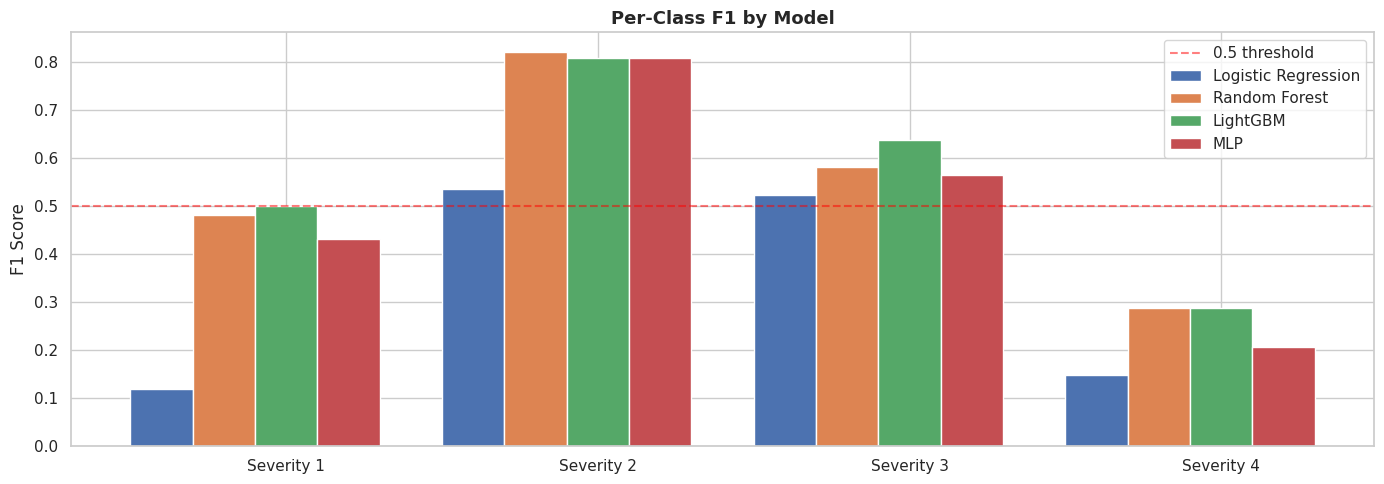

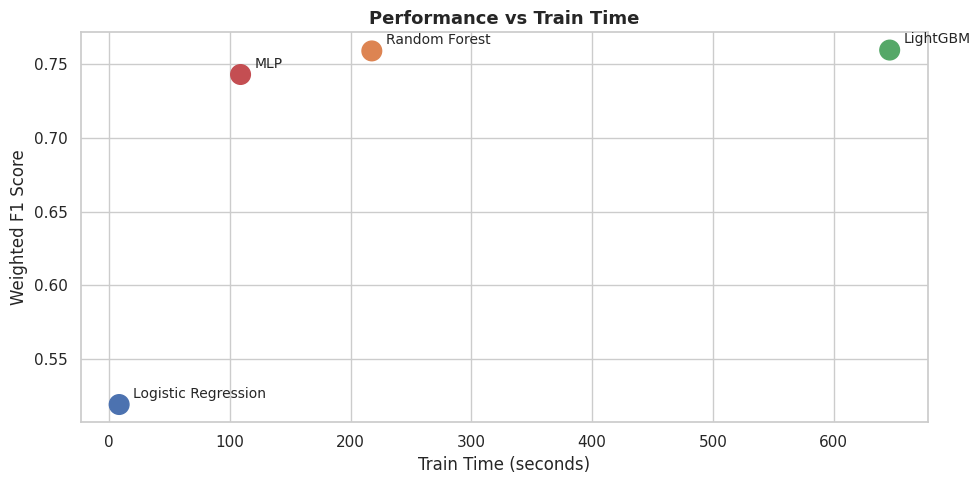

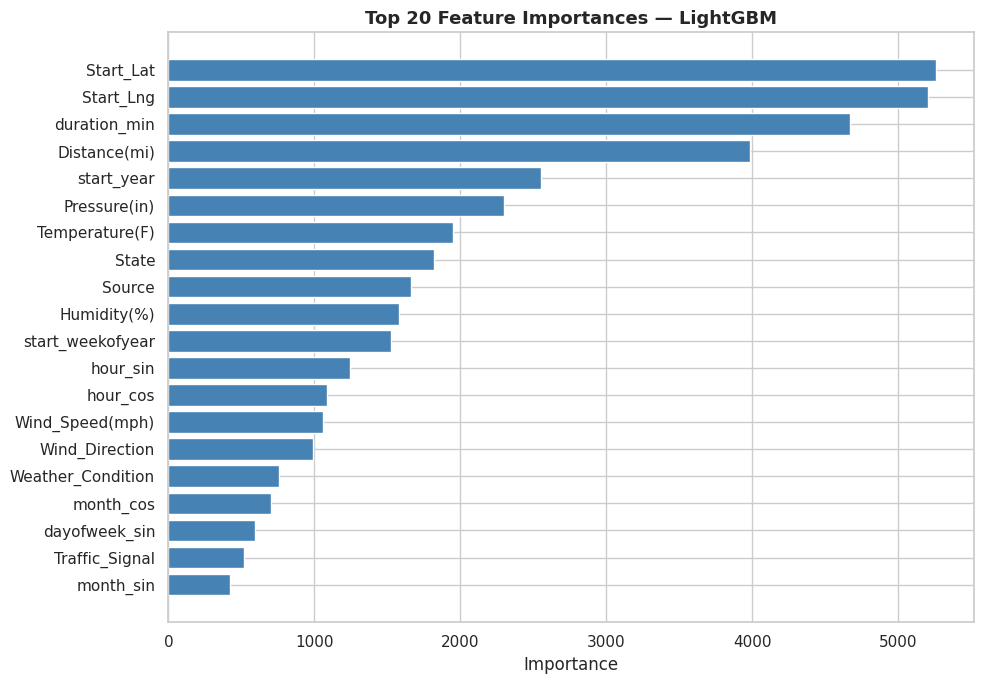


BEST MODEL: LightGBM
Weighted F1: 0.7595


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

# ============================================================
# SUMMARY TABLE
# ============================================================
summary = pd.DataFrame({
    name: {
        'Weighted F1': f"{v['weighted_f1']:.4f}",
        'F1 Sev1':     f"{v['f1_per_class'][0]:.4f}",
        'F1 Sev2':     f"{v['f1_per_class'][1]:.4f}",
        'F1 Sev3':     f"{v['f1_per_class'][2]:.4f}",
        'F1 Sev4':     f"{v['f1_per_class'][3]:.4f}",
        'Train Time':  f"{v['train_time']:.1f}s",
        'Sample Size': f"{v['sample_size']:,}",
    }
    for name, v in results.items()
}).T
print(summary.to_string())

# ============================================================
# CHART 1 — Weighted F1 comparison
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
names  = list(results.keys())
f1s    = [results[n]['weighted_f1'] for n in names]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars   = ax.bar(names, f1s, color=colors[:len(names)], width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_ylabel('Weighted F1 Score')
ax.set_title('Model Comparison — Weighted F1', fontsize=13, fontweight='bold')

# highlight best model
best_idx = f1s.index(max(f1s))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# ============================================================
# CHART 2 — Per-class F1
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(4)
width = 0.2
for i, (name, color) in enumerate(zip(names, colors)):
    ax.bar(x + i*width, results[name]['f1_per_class'],
           width, label=name, color=color)
ax.set_xticks(x + width * (len(names)/2))
ax.set_xticklabels(['Severity 1', 'Severity 2', 'Severity 3', 'Severity 4'])
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 by Model', fontsize=13, fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='0.5 threshold')
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# CHART 3 — Train time vs performance
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
times = [results[n]['train_time'] for n in names]
scatter = ax.scatter(times, f1s, c=colors[:len(names)], s=200, zorder=5)
for i, name in enumerate(names):
    ax.annotate(name, (times[i], f1s[i]),
                textcoords='offset points', xytext=(10, 5), fontsize=10)
ax.set_xlabel('Train Time (seconds)')
ax.set_ylabel('Weighted F1 Score')
ax.set_title('Performance vs Train Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# CHART 4 — Feature importance (LightGBM)
# ============================================================
importance_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': lgbm_best.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(importance_df['feature'][::-1],
         importance_df['importance'][::-1], color='steelblue')
plt.title('Top 20 Feature Importances — LightGBM',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# ============================================================
# FINAL VERDICT
# ============================================================
best_model = max(results, key=lambda x: results[x]['weighted_f1'])
print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model}")
print(f"Weighted F1: {results[best_model]['weighted_f1']:.4f}")
print(f"{'='*60}")


### Output

The final comparison shows that LightGBM was the best model with the highest weighted F1-score (**0.7595**), but it was only slightly better than Random Forest (**0.7589**).

Main results:

- LightGBM had the best overall score
- Random Forest was almost the same and trained much faster
- MLP was acceptable but weaker than the tree models
- Logistic Regression was clearly the weakest model

Per-class results:

- Severity 2 was predicted best by all models
- Severity 3 had moderate results
- Severity 1 improved most with LightGBM
- Severity 4 was weak for every model

Feature importance shows the most useful variables were:

- Start latitude and longitude
- Accident duration
- Distance
- Year
- Weather variables

Overall, LightGBM was selected as the final model, but Random Forest gave similar accuracy with lower training time.

## Conclusions

* The goal of this project was to predict accident severity using machine learning models on a large U.S. accident dataset.

* Several models were tested, including Logistic Regression, Random Forest, LightGBM, and MLP Neural Network.

* LightGBM achieved the best overall performance with a weighted F1-score of 0.7595. Random Forest gave very similar results with faster training time.

* Severity 2 was predicted well by all models, while Severity 4 was the hardest class to predict because it had fewer samples.

* One major challenge in this project was class imbalance. Most rows belonged to Severity 2, while Severity 1 and Severity 4 had much fewer examples. Because of this, models learned the majority class more easily and had weaker performance on rare classes.

* Important features included location, accident duration, distance, time, and weather variables.

* Some limitations of this project include class imbalance, large data size, and limited training time for more complex tuning.

* In future work, model performance may improve by using better balancing methods, more feature engineering, and advanced models such as XGBoost or CatBoost.